# Roulette Fraud Detection — Feature Engineering & Baseline Modeling

**Self-contained notebook.** No dependency on `fraud_eda.ipynb` state.

## Sections
1. Setup and Configuration
2. Data Loading (cache → MongoDB → fallback)
3. Label Reconstruction
4. Draw-Level Feature Engineering
5. Player-Level Feature Table
6. Feature Quality Checks
7. Train / Validation Split
8. Preprocessing Pipeline
9. Baseline Models (Logistic Regression, Random Forest, LightGBM)
10. Evaluation
11. Explainability (Feature Importance + SHAP)
12. Error Analysis
13. Save Outputs
14. Conclusions

**Labeling caveat:** `label=0` means *not currently matched as fraud*, not *proven clean*. The negative class is weakly labeled.

In [1]:
print("Hello world")

Hello world


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — SETUP AND CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
import json
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import entropy as scipy_entropy
from dotenv import load_dotenv

# MongoDB
try:
    from pymongo import MongoClient
    from pymongo.errors import PyMongoError
    from bson import json_util
    MONGO_AVAILABLE = True
except ImportError:
    MONGO_AVAILABLE = False
    print("pymongo not available — MongoDB pull disabled")

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
)

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("lightgbm not available — LightGBM model skipped")

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("shap not available — SHAP analysis skipped")

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.4f}".format)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print("All imports successful.")

All imports successful.


In [3]:
# ── Paths and constants ───────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / ".env").exists() and (PROJECT_ROOT.parent / ".env").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

load_dotenv(PROJECT_ROOT / ".env", override=True)

DATA_DIR = PROJECT_ROOT / "data_cache"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# MongoDB config
MONGODB_URI          = os.getenv("MONGODB_URI")
DATABASE_NAME        = os.getenv("MONGODB_DATABASE", "gk-reports")
ROULETTE_COLLECTION  = os.getenv("MONGODB_COLLECTION_ROULETTE_REPORT", "roulette_game_report")
CCS_COLLECTION       = os.getenv("MONGODB_COLLECTION_CCS", "ccs")
USERS_COLLECTION     = os.getenv("MONGODB_COLLECTION_USERS", "gk_users")

# Fraud CSV
FRAUD_CSV_PATH = PROJECT_ROOT / "ROULET CHEATING DATA.csv"

# Cache paths
FRAUD_PULL_CACHE         = DATA_DIR / "fraud_modeling_pull.parquet"
PLAYER_FEATURE_TABLE_PATH = DATA_DIR / "player_feature_table.parquet"
FEATURE_DICT_PATH        = DATA_DIR / "player_feature_dictionary.csv"
TRAIN_DATASET_PATH       = DATA_DIR / "model_train_dataset.parquet"
METRICS_PATH             = DATA_DIR / "baseline_metrics.json"
FEATURE_IMPORTANCE_PATH  = DATA_DIR / "feature_importance.csv"

# Reproducibility
RANDOM_SEED = 42
TEST_SIZE   = 0.30

print(f"Project root : {PROJECT_ROOT}")
print(f"Data cache   : {DATA_DIR}")
print(f"MongoDB URI  : {'configured' if MONGODB_URI else 'NOT CONFIGURED'}")
print(f"Database     : {DATABASE_NAME}")
print(f"Fraud CSV    : {'found' if FRAUD_CSV_PATH.exists() else 'NOT FOUND'}")

Project root : c:\Users\PC\Documents\Fraud Detection
Data cache   : c:\Users\PC\Documents\Fraud Detection\data_cache
MongoDB URI  : configured
Database     : gk-reports
Fraud CSV    : found


In [4]:
# ── Helper functions ──────────────────────────────────────────────────────────

def normalize_records(records: list) -> pd.DataFrame:
    """Convert MongoDB documents → flat DataFrame, handling BSON types."""
    if not records:
        return pd.DataFrame()
    serialized = json.loads(json_util.dumps(records))
    return pd.json_normalize(serialized)


def parse_bets(value) -> list:
    """Parse bets field — handles list (MongoDB) and JSON string (Parquet)."""
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            return json.loads(value)
        except (json.JSONDecodeError, TypeError):
            return []
    return []


def detect_timestamp_col(df: pd.DataFrame) -> str | None:
    for candidate in ["createdAt.$date", "trans_date.$date", "updatedAt.$date", "ts"]:
        if candidate in df.columns:
            return candidate
    return None


def bet_entropy(bets_list: list) -> float:
    """Shannon entropy of the bet-amount distribution within a draw."""
    amounts = np.array([float(b.get("bet_amount", 0) or 0) for b in bets_list])
    amounts = amounts[amounts > 0]
    if len(amounts) == 0 or amounts.sum() == 0:
        return 0.0
    probs = amounts / amounts.sum()
    return float(scipy_entropy(probs, base=2))


def bet_gini(bets_list: list) -> float:
    """Gini coefficient of bet-amount distribution (0=equal, 1=maximally unequal)."""
    arr = np.array([float(b.get("bet_amount", 0) or 0) for b in bets_list])
    arr = arr[arr > 0]
    if len(arr) == 0:
        return 0.0
    n = len(arr)
    arr_sorted = np.sort(arr)
    cumsum = np.cumsum(arr_sorted)
    total = cumsum[-1]
    if total == 0:
        return 0.0
    return float((2.0 * np.sum((np.arange(1, n + 1)) * arr_sorted) / (n * total)) - (n + 1) / n)


def make_bet_template(bets_list: list) -> tuple:
    """Canonical sorted (position, amount) fingerprint for a single draw."""
    return tuple(sorted(
        (str(b.get("number", "")), round(float(b.get("bet_amount", 0) or 0), 6))
        for b in bets_list
        if float(b.get("bet_amount", 0) or 0) > 0
    ))


def section(title: str):
    print(f"\n{'=' * 70}\n  {title}\n{'=' * 70}")


def eval_model(name: str, y_true, y_pred, y_prob, metrics_store: dict):
    """Compute and print fraud-focused metrics; store results in metrics_store."""
    if len(np.unique(y_true)) < 2:
        print(f"  {name}: only one class in y_true — skipping metrics")
        return
    roc  = roc_auc_score(y_true, y_prob)
    prc  = average_precision_score(y_true, y_prob)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)
    print(f"  ROC-AUC: {roc:.4f}  |  PR-AUC: {prc:.4f}  |  F1: {f1:.4f}")
    print(f"  Precision: {prec:.4f}  |  Recall: {rec:.4f}")
    print(f"  Confusion matrix:\n{cm}")
    metrics_store[name] = {
        "roc_auc": round(roc, 4), "pr_auc": round(prc, 4),
        "precision": round(prec, 4), "recall": round(rec, 4),
        "f1": round(f1, 4),
        "confusion_matrix": cm.tolist(),
    }


print("Helper functions defined.")

Helper functions defined.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — FRAUD CSV LOADING
# ─────────────────────────────────────────────────────────────────────────────
section("FRAUD CSV LOADING")

assert FRAUD_CSV_PATH.exists(), f"Fraud CSV not found at: {FRAUD_CSV_PATH}"

fraud_csv = pd.read_csv(FRAUD_CSV_PATH)
fraud_csv.columns = [c.strip().lower() for c in fraud_csv.columns]
fraud_csv["draw_id"]   = pd.to_numeric(fraud_csv["draw_id"], errors="coerce").astype("Int64")
fraud_csv["member_id"] = fraud_csv["member_id"].astype(str).str.strip().str.upper()
fraud_csv["ccs_id"]    = fraud_csv["ccs_id"].astype(str).str.strip()
fraud_csv["date"]      = pd.to_datetime(fraud_csv["date"], format="%m/%d/%Y", errors="coerce")
fraud_csv = fraud_csv.drop_duplicates(subset=["draw_id", "member_id"])

FRAUD_DRAW_IDS   = fraud_csv["draw_id"].dropna().astype(int).unique().tolist()
FRAUD_MEMBER_IDS = fraud_csv["member_id"].dropna().unique().tolist()
FRAUD_MEMBER_SET = set(FRAUD_MEMBER_IDS)

print(f"Rows          : {len(fraud_csv):,}")
print(f"Unique draws  : {len(FRAUD_DRAW_IDS):,}")
print(f"Unique members: {len(FRAUD_MEMBER_IDS):,}")
print(f"Unique CCS IDs: {fraud_csv['ccs_id'].nunique():,}")
print(f"Date range    : {fraud_csv['date'].min().date()} → {fraud_csv['date'].max().date()}")
fraud_csv.head()


  FRAUD CSV LOADING
Rows          : 437
Unique draws  : 79
Unique members: 402
Unique CCS IDs: 304
Date range    : 2025-12-17 → 2026-04-03


,date,draw_id,member_id,ccs_id
0,2025-12-18,7102365,GK00206537,4778
1,2025-12-18,7102365,GK00253494,7871
2,2025-12-18,7102312,GK00229367,17910
3,2025-12-18,7102312,GK00242974,4179
4,2025-12-18,7102213,GK00251373,4624


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 (cont.) — ROULETTE DATA LOADING
# Priority: (1) fraud_modeling_pull.parquet cache
#           (2) MongoDB pull using fraud draw_ids + member_ids
#           (3) roulette_game_report_sample.parquet fallback (no fraud overlap)
# ─────────────────────────────────────────────────────────────────────────────
section("ROULETTE DATA LOADING")

roulette_df = pd.DataFrame()
load_source = "none"

# ── (1) Try dedicated modeling cache ─────────────────────────────────────────
if FRAUD_PULL_CACHE.exists():
    print(f"Loading from modeling cache: {FRAUD_PULL_CACHE.name}")
    roulette_df = pd.read_parquet(FRAUD_PULL_CACHE)
    load_source = "cache"
    print(f"Loaded {len(roulette_df):,} rows")

# ── (2) MongoDB pull ──────────────────────────────────────────────────────────
elif MONGODB_URI and MONGO_AVAILABLE:
    print("No modeling cache found. Pulling from MongoDB...")
    try:
        client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=20000)
        client.admin.command("ping")
        db = client[DATABASE_NAME]
        col = db[ROULETTE_COLLECTION]

        # Pull A — all players in the fraud-labeled draws (gives comparison population)
        print(f"  Pull A: fraud draw_ids ({len(FRAUD_DRAW_IDS)})...")
        draw_records = list(col.find({"draw_id": {"$in": FRAUD_DRAW_IDS}}, {"_id": 0}))
        print(f"  Got {len(draw_records):,} rows from draw-id pull")

        # Pull B — full history for all fraud member_ids
        print(f"  Pull B: fraud member_ids ({len(FRAUD_MEMBER_IDS)})...")
        member_records = list(col.find({"member_id": {"$in": FRAUD_MEMBER_IDS}}, {"_id": 0}))
        print(f"  Got {len(member_records):,} rows from member-id pull")

        client.close()

        draw_df   = normalize_records(draw_records)
        member_df = normalize_records(member_records)
        roulette_df = pd.concat([draw_df, member_df], ignore_index=True)

        # Deduplicate on draw_id + member_id
        roulette_df["_dedup"] = (
            roulette_df["draw_id"].astype(str) + "|" + roulette_df["member_id"].astype(str)
        )
        before = len(roulette_df)
        roulette_df = roulette_df.drop_duplicates(subset=["_dedup"]).drop(columns=["_dedup"])
        print(f"  Combined: {before:,} → {len(roulette_df):,} after dedup")

        roulette_df.to_parquet(FRAUD_PULL_CACHE, index=False)
        print(f"  Cached to {FRAUD_PULL_CACHE.name}")
        load_source = "mongodb"

    except Exception as e:
        print(f"  MongoDB pull failed: {e}")
        print("  Will try sample fallback...")

# ── (3) Sample fallback ───────────────────────────────────────────────────────
if roulette_df.empty:
    fallback = DATA_DIR / "roulette_game_report_sample.parquet"
    if fallback.exists():
        roulette_df = pd.read_parquet(fallback)
        load_source = "sample_fallback"
        print(f"Using fallback sample: {len(roulette_df):,} rows")
        print("WARNING: Sample data has no overlap with fraud labels.")
        print("Feature engineering will run. Supervised modeling will be skipped.")
    else:
        raise FileNotFoundError(
            "No roulette data found. Connect to MongoDB or ensure data_cache exists."
        )

print(f"\nLoad source: {load_source}")
print(f"Shape: {roulette_df.shape}")


  ROULETTE DATA LOADING
Loading from modeling cache: fraud_modeling_pull.parquet
Loaded 48,385 rows

Load source: cache
Shape: (48385, 26)


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 (cont.) — SCHEMA VALIDATION
# ─────────────────────────────────────────────────────────────────────────────
section("SCHEMA VALIDATION")

REQUIRED = ["member_id", "draw_id", "total_bet_amount", "win_points"]
missing_cols = [c for c in REQUIRED if c not in roulette_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")
print("All required columns present.")

# Normalize identifiers
roulette_df["member_id"] = roulette_df["member_id"].astype(str).str.strip().str.upper()
roulette_df["draw_id"]   = pd.to_numeric(roulette_df["draw_id"], errors="coerce").astype("Int64")

# Numeric monetary columns
roulette_df["total_bet_amount"] = pd.to_numeric(roulette_df["total_bet_amount"], errors="coerce").fillna(0.0)
roulette_df["win_points"]       = pd.to_numeric(roulette_df["win_points"],       errors="coerce").fillna(0.0)
roulette_df["net_result"]       = roulette_df["win_points"] - roulette_df["total_bet_amount"]

# Parse bets
if "bets" in roulette_df.columns:
    roulette_df["bets"] = roulette_df["bets"].apply(parse_bets)
    BETS_PRESENT = True
else:
    roulette_df["bets"] = [[] for _ in range(len(roulette_df))]
    BETS_PRESENT = False
    print("WARNING: 'bets' column missing — bet-level features will be zero-filled.")

# Timestamp
ts_col = detect_timestamp_col(roulette_df)
if ts_col:
    roulette_df["ts"] = pd.to_datetime(roulette_df[ts_col], errors="coerce", utc=True)
    TS_PRESENT = True
else:
    roulette_df["ts"] = pd.NaT
    TS_PRESENT = False
    print("WARNING: No timestamp column detected — timing features will be NaN.")

# CCS and session IDs
roulette_df["ccs_id"]    = roulette_df.get("ccs_id", pd.Series("UNKNOWN", index=roulette_df.index)).astype(str).str.strip()
roulette_df["session_id"] = roulette_df.get("session_id", pd.Series(pd.NA, index=roulette_df.index)).astype(str)

# Drop rows with null draw_id or member_id (unusable for feature engineering)
before = len(roulette_df)
roulette_df = roulette_df.dropna(subset=["draw_id", "member_id"]).reset_index(drop=True)
print(f"Dropped {before - len(roulette_df):,} rows with null draw_id or member_id")

print(f"\nFinal rows       : {len(roulette_df):,}")
print(f"Unique players   : {roulette_df['member_id'].nunique():,}")
print(f"Unique draws     : {roulette_df['draw_id'].nunique():,}")
print(f"Bets present     : {BETS_PRESENT}")
print(f"Timestamp present: {TS_PRESENT}")
if TS_PRESENT:
    print(f"Date range       : {roulette_df['ts'].min()} → {roulette_df['ts'].max()}")


  SCHEMA VALIDATION
All required columns present.
Dropped 0 rows with null draw_id or member_id

Final rows       : 48,385
Unique players   : 1,049
Unique draws     : 23,312
Bets present     : True
Timestamp present: True
Date range       : 2026-01-05 08:53:24.156000+00:00 → 2026-03-29 14:26:30.892000+00:00


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — LABEL RECONSTRUCTION
# ─────────────────────────────────────────────────────────────────────────────
section("LABEL RECONSTRUCTION")

# Label rule:
#   label = 1  if member_id appears in the analyst-reviewed fraud CSV
#   label = 0  otherwise (not currently matched — weakly labeled negative)

roulette_df["label"] = roulette_df["member_id"].isin(FRAUD_MEMBER_SET).astype(int)

n_fraud_rows    = roulette_df["label"].sum()
n_nonfraud_rows = (roulette_df["label"] == 0).sum()
n_fraud_players    = roulette_df[roulette_df["label"] == 1]["member_id"].nunique()
n_nonfraud_players = roulette_df[roulette_df["label"] == 0]["member_id"].nunique()

print("Labeling rule: label=1 if member_id in fraud CSV, label=0 otherwise.")
print("NOTE: label=0 does NOT mean proven clean — negative class is weakly labeled.\n")
print(f"Draw-level rows   — fraud: {n_fraud_rows:,}  |  non-fraud: {n_nonfraud_rows:,}  |  fraud rate: {roulette_df['label'].mean():.2%}")
print(f"Unique players    — fraud: {n_fraud_players:,}  |  non-fraud: {n_nonfraud_players:,}")
print(f"\nFraud members in CSV not seen in data: {len(FRAUD_MEMBER_SET - set(roulette_df[roulette_df['label']==1]['member_id'].unique())):,} / {len(FRAUD_MEMBER_IDS)}")

CAN_MODEL = n_fraud_players >= 5
if not CAN_MODEL:
    print("\nWARNING: Fewer than 5 fraud players found in data. Supervised modeling will be skipped.")
    print("Feature engineering will still run to validate the pipeline.")
else:
    print(f"\nModeling feasibility: YES — {n_fraud_players} fraud players found.")


  LABEL RECONSTRUCTION
Labeling rule: label=1 if member_id in fraud CSV, label=0 otherwise.
NOTE: label=0 does NOT mean proven clean — negative class is weakly labeled.

Draw-level rows   — fraud: 45,385  |  non-fraud: 3,000  |  fraud rate: 93.80%
Unique players    — fraud: 227  |  non-fraud: 822

Fraud members in CSV not seen in data: 175 / 402

Modeling feasibility: YES — 227 fraud players found.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — DRAW-LEVEL FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────
section("DRAW-LEVEL FEATURE ENGINEERING")

bets = roulette_df["bets"]

# ── Bet count features ────────────────────────────────────────────────────────
roulette_df["bets_per_draw"] = bets.apply(len)
roulette_df["nonzero_bets_per_draw"] = bets.apply(
    lambda v: sum(float(b.get("bet_amount", 0) or 0) > 0 for b in v)
)
roulette_df["tiny_bets_per_draw"] = bets.apply(
    lambda v: sum(0 < float(b.get("bet_amount", 0) or 0) <= 1 for b in v)
)
roulette_df["tiny_bet_ratio_in_draw"] = np.where(
    roulette_df["bets_per_draw"] > 0,
    roulette_df["tiny_bets_per_draw"] / roulette_df["bets_per_draw"],
    0.0,
)

# ── Bet concentration features ────────────────────────────────────────────────
roulette_df["max_bet_amount_in_draw"] = bets.apply(
    lambda v: max((float(b.get("bet_amount", 0) or 0) for b in v), default=0.0)
)
roulette_df["max_bet_share_in_draw"] = np.where(
    roulette_df["total_bet_amount"] > 0,
    (roulette_df["max_bet_amount_in_draw"] / roulette_df["total_bet_amount"]).clip(0, 1),
    0.0,
)
roulette_df["bet_amount_mean_in_draw"] = bets.apply(
    lambda v: float(np.mean([float(b.get("bet_amount", 0) or 0) for b in v])) if v else 0.0
)
roulette_df["bet_amount_std_in_draw"] = bets.apply(
    lambda v: float(np.std([float(b.get("bet_amount", 0) or 0) for b in v])) if len(v) > 1 else 0.0
)

# ── Information-theoretic features ───────────────────────────────────────────
roulette_df["entropy_in_draw"] = bets.apply(bet_entropy)
roulette_df["gini_in_draw"]    = bets.apply(bet_gini)

# ── Template fingerprint ──────────────────────────────────────────────────────
roulette_df["bet_template"] = bets.apply(make_bet_template)

# ── Timing features (requires timestamp) ─────────────────────────────────────
if TS_PRESENT:
    roulette_df = roulette_df.sort_values(["member_id", "ts"]).copy()
    roulette_df["inter_draw_seconds"] = (
        roulette_df.groupby("member_id")["ts"].diff().dt.total_seconds()
    )
    roulette_df["hour_of_day"]  = roulette_df["ts"].dt.hour
    roulette_df["day_of_week"]  = roulette_df["ts"].dt.dayofweek
    roulette_df["is_night"]     = (
        (roulette_df["hour_of_day"] >= 22) | (roulette_df["hour_of_day"] <= 5)
    ).astype(int)
    roulette_df["is_weekend"]   = (roulette_df["day_of_week"] >= 5).astype(int)
else:
    for col in ["inter_draw_seconds", "hour_of_day", "day_of_week", "is_night", "is_weekend"]:
        roulette_df[col] = np.nan

# Result outcome helpers
roulette_df["is_positive_result"] = (roulette_df["net_result"] > 0).astype(int)

draw_feat_cols = [
    "bets_per_draw", "nonzero_bets_per_draw", "tiny_bet_ratio_in_draw",
    "max_bet_share_in_draw", "bet_amount_std_in_draw", "entropy_in_draw", "gini_in_draw",
]
print("Draw-level features computed:")
print(roulette_df[draw_feat_cols].describe().T[["mean", "std", "min", "max"]])


  DRAW-LEVEL FEATURE ENGINEERING
Draw-level features computed:
                          mean      std     min       max
bets_per_draw          38.0000   0.0000 38.0000   38.0000
nonzero_bets_per_draw  18.7708   9.3815  0.0000   38.0000
tiny_bet_ratio_in_draw  0.1570   0.2844  0.0000    1.0000
max_bet_share_in_draw   0.1522   0.1524  0.0000    1.0000
bet_amount_std_in_draw 30.5740 119.6703  0.0000 3414.7209
entropy_in_draw         3.7724   1.0580  0.0000    5.2436
gini_in_draw            0.2022   0.1629 -0.0000    0.9236


In [10]:
# ── Template reuse stats per player (needed before player agg) ────────────────
section("BET TEMPLATE REPETITION ANALYSIS")

def _max_template_count(templates: pd.Series) -> int:
    if templates.empty:
        return 0
    counts = templates.value_counts()
    return int(counts.iloc[0]) if not counts.empty else 0

def _top_template_share(templates: pd.Series) -> float:
    if templates.empty:
        return 0.0
    counts = templates.value_counts()
    return float(counts.iloc[0]) / len(templates) if not counts.empty else 0.0

template_df = (
    roulette_df.groupby("member_id")["bet_template"]
    .agg(
        draws_total="count",
        unique_templates="nunique",
        max_template_reuse=_max_template_count,
        top_template_share=_top_template_share,
    )
    .reset_index()
)
template_df["template_reuse_ratio"] = (
    1.0 - (template_df["unique_templates"] / template_df["draws_total"].replace(0, np.nan))
).fillna(0.0).clip(0, 1)

# Quick validation
print(f"Players with template_reuse_ratio == 1.0 (fully scripted): "
      f"{(template_df['template_reuse_ratio'] == 1.0).sum():,}")
print(f"Median template reuse ratio: {template_df['template_reuse_ratio'].median():.4f}")
print()
print(template_df[["template_reuse_ratio", "max_template_reuse", "top_template_share"]].describe())


  BET TEMPLATE REPETITION ANALYSIS
Players with template_reuse_ratio == 1.0 (fully scripted): 0
Median template reuse ratio: 0.0000

       template_reuse_ratio  max_template_reuse  top_template_share
count             1049.0000           1049.0000           1049.0000
mean                 0.1344              7.6015              0.3742
std                  0.2961             30.4472              0.2954
min                  0.0000              1.0000              0.0011
25%                  0.0000              1.0000              0.2000
50%                  0.0000              1.0000              0.2500
75%                  0.0000              1.0000              0.5000
max                  0.9975            397.0000              1.0000


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — PLAYER-LEVEL FEATURE TABLE
# ─────────────────────────────────────────────────────────────────────────────
section("PLAYER-LEVEL FEATURE TABLE")

# ── A. Volume and participation features ─────────────────────────────────────
agg_spec = {
    "draw_id":               [("draws_played", "nunique")],
    "total_bet_amount":      [("total_staked", "sum"), ("avg_stake_per_draw", "mean"),
                              ("median_stake_per_draw", "median"), ("stake_std", "std"),
                              ("max_stake_per_draw", "max"), ("min_stake_per_draw", "min")],
    # B. Timing and cadence
    "inter_draw_seconds":    [("avg_inter_draw_seconds", "mean"), ("std_inter_draw_seconds", "std"),
                              ("median_inter_draw_seconds", "median"), ("min_inter_draw_seconds", "min")],
    # C. Bet shape
    "nonzero_bets_per_draw": [("avg_nonzero_bets_per_draw", "mean"), ("median_nonzero_bets_per_draw", "median")],
    "max_bet_share_in_draw": [("avg_max_bet_share", "mean"), ("median_max_bet_share", "median")],
    "bet_amount_std_in_draw":[("avg_bet_amount_std_in_draw", "mean")],
    "bet_amount_mean_in_draw":[("avg_bet_amount_mean_in_draw", "mean")],
    "entropy_in_draw":       [("avg_entropy", "mean"), ("entropy_std", "std")],
    "gini_in_draw":          [("avg_gini", "mean")],
    "tiny_bet_ratio_in_draw":[("avg_tiny_bet_ratio", "mean")],
    # E. Outcome and volatility
    "net_result":            [("avg_net_result", "mean"), ("median_net_result", "median"),
                              ("std_net_result", "std"), ("total_net_result", "sum")],
    "win_points":            [("total_won", "sum")],
    "is_positive_result":    [("positive_draw_rate", "mean")],
    # G. Contextual temporal
    "is_night":              [("night_play_ratio", "mean")],
    "is_weekend":            [("weekend_play_ratio", "mean")],
}

player_agg = roulette_df.groupby("member_id").agg(**{
    new_name: pd.NamedAgg(column=col, aggfunc=func)
    for col, aggs in agg_spec.items()
    for new_name, func in aggs
}).reset_index()

# ── Derived volume features ───────────────────────────────────────────────────
player_agg["stake_cv"] = (
    player_agg["stake_std"] / player_agg["avg_stake_per_draw"].replace(0, np.nan)
).fillna(0.0)
player_agg["win_to_stake_ratio"] = (
    player_agg["total_won"] / player_agg["total_staked"].replace(0, np.nan)
).fillna(0.0)
player_agg["pnl_volatility"] = player_agg["std_net_result"].fillna(0.0)

# ── Session features ──────────────────────────────────────────────────────────
sess_agg = roulette_df.groupby("member_id")["session_id"].agg(sessions_played="nunique").reset_index()
player_agg = player_agg.merge(sess_agg, on="member_id", how="left")
player_agg["avg_draws_per_session"] = (
    player_agg["draws_played"] / player_agg["sessions_played"].replace(0, np.nan)
).fillna(0.0)

# ── Temporal span features ────────────────────────────────────────────────────
if TS_PRESENT:
    date_range = roulette_df.groupby("member_id")["ts"].agg(ts_min="min", ts_max="max").reset_index()
    date_range["active_days"] = (
        (date_range["ts_max"] - date_range["ts_min"]).dt.total_seconds() / 86400 + 1
    )
    player_agg = player_agg.merge(date_range[["member_id", "active_days"]], on="member_id", how="left")
    player_agg["draws_per_active_day"] = (
        player_agg["draws_played"] / player_agg["active_days"].replace(0, np.nan)
    ).fillna(0.0)
else:
    player_agg["active_days"]        = np.nan
    player_agg["draws_per_active_day"] = np.nan

# ── CCS context features ──────────────────────────────────────────────────────
ccs_nunique = roulette_df.groupby("member_id")["ccs_id"].nunique().reset_index(name="ccs_seen_count")
player_agg = player_agg.merge(ccs_nunique, on="member_id", how="left")

primary_ccs = (
    roulette_df.groupby("member_id")["ccs_id"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "UNKNOWN")
    .reset_index(name="primary_ccs_id")
)
player_agg = player_agg.merge(primary_ccs, on="member_id", how="left")

# Primary CCS share = fraction of draws in the dominant CCS bucket
ccs_counts = roulette_df.groupby(["member_id", "ccs_id"]).size().reset_index(name="cnt")
primary_ccs_cnt = ccs_counts.loc[ccs_counts.groupby("member_id")["cnt"].idxmax(), ["member_id", "cnt"]]
player_agg = player_agg.merge(primary_ccs_cnt.rename(columns={"cnt": "_prim_ccs_cnt"}), on="member_id", how="left")
player_agg["primary_ccs_share"] = (
    player_agg["_prim_ccs_cnt"] / player_agg["draws_played"].replace(0, np.nan)
).fillna(0.0)
player_agg = player_agg.drop(columns=["_prim_ccs_cnt"])

# ── Merge template stats ──────────────────────────────────────────────────────
player_agg = player_agg.merge(
    template_df[["member_id", "unique_templates", "template_reuse_ratio",
                 "max_template_reuse", "top_template_share"]],
    on="member_id", how="left"
)

# ── Label ─────────────────────────────────────────────────────────────────────
player_labels = roulette_df.groupby("member_id")["label"].max().reset_index()
player_agg = player_agg.merge(player_labels, on="member_id", how="left")
player_agg["label"] = player_agg["label"].fillna(0).astype(int)

print(f"Player feature table shape: {player_agg.shape}")
print(f"  Fraud players   (label=1): {(player_agg['label'] == 1).sum():,}")
print(f"  Non-fraud players (label=0): {(player_agg['label'] == 0).sum():,}")
print(f"  Feature columns: {len(player_agg.columns) - 2}")


  PLAYER-LEVEL FEATURE TABLE
Player feature table shape: (1049, 45)
  Fraud players   (label=1): 227
  Non-fraud players (label=0): 822
  Feature columns: 43


In [12]:
# ── Feature dictionary ────────────────────────────────────────────────────────
FEATURE_DICT = {
    # Volume & participation
    "draws_played":              "Total unique draws the player participated in",
    "sessions_played":           "Total unique sessions observed for the player",
    "active_days":               "Number of calendar days active (first to last draw)",
    "total_staked":              "Total amount wagered across all draws",
    "avg_stake_per_draw":        "Mean wager per draw",
    "median_stake_per_draw":     "Median wager per draw",
    "stake_std":                 "Standard deviation of per-draw wager",
    "max_stake_per_draw":        "Maximum wager in any single draw",
    "min_stake_per_draw":        "Minimum wager in any single draw",
    "stake_cv":                  "Coefficient of variation of per-draw wager (stake_std / avg_stake)",
    # Timing & cadence
    "avg_inter_draw_seconds":    "Mean time between consecutive draws (seconds)",
    "std_inter_draw_seconds":    "Std dev of inter-draw gap — low = highly regular cadence",
    "median_inter_draw_seconds": "Median inter-draw gap",
    "min_inter_draw_seconds":    "Shortest gap between two draws — very low = burst play",
    "avg_draws_per_session":     "Average draws played within each session",
    "draws_per_active_day":      "Draws per day of observed activity",
    # Bet shape & concentration
    "avg_nonzero_bets_per_draw": "Mean number of positions with positive stake per draw",
    "median_nonzero_bets_per_draw": "Median positive-stake positions per draw",
    "avg_max_bet_share":         "Mean fraction of total wager on the largest single position",
    "median_max_bet_share":      "Median largest-position stake share",
    "avg_bet_amount_std_in_draw":"Mean within-draw std dev of per-position bet amounts",
    "avg_bet_amount_mean_in_draw": "Mean within-draw mean per-position bet amount",
    "avg_entropy":               "Mean Shannon entropy of bet distribution across positions",
    "entropy_std":               "Std dev of per-draw entropy — low = consistently scripted",
    "avg_gini":                  "Mean Gini coefficient of bet distribution",
    "avg_tiny_bet_ratio":        "Mean fraction of bets ≤ 1 unit (tiny/minimum bets)",
    # Repetition & template
    "unique_templates":          "Number of distinct bet-pattern fingerprints observed",
    "template_reuse_ratio":      "1 - (unique_templates / draws_played); 1.0 = fully scripted",
    "max_template_reuse":        "Most times any single template was repeated",
    "top_template_share":        "Fraction of draws using the most common template",
    # Outcome & volatility
    "avg_net_result":            "Mean per-draw net profit/loss (win - stake)",
    "median_net_result":         "Median per-draw net result",
    "std_net_result":            "Std dev of per-draw net result",
    "total_net_result":          "Cumulative net profit/loss across all draws",
    "positive_draw_rate":        "Fraction of draws where the player won (net > 0)",
    "win_to_stake_ratio":        "total_won / total_staked — overall return rate",
    "pnl_volatility":            "Std dev of net result (same as std_net_result)",
    # Contextual
    "ccs_seen_count":            "Number of distinct CCS manager buckets observed",
    "primary_ccs_share":         "Fraction of draws in the player's dominant CCS bucket",
    "night_play_ratio":          "Fraction of draws occurring between 22:00–05:59 UTC",
    "weekend_play_ratio":        "Fraction of draws on Saturday or Sunday",
}

feat_dict_df = pd.DataFrame(
    [(feat, desc) for feat, desc in FEATURE_DICT.items()],
    columns=["feature", "description"]
)
print(f"Feature dictionary: {len(feat_dict_df)} features")
feat_dict_df

Feature dictionary: 41 features


,feature,description
0,draws_played,Total unique draws the player participated in
1,sessions_played,Total unique sessions observed for the player
2,active_days,Number of calendar days active (first to last ...
3,total_staked,Total amount wagered across all draws
4,avg_stake_per_draw,Mean wager per draw
5,median_stake_per_draw,Median wager per draw
6,stake_std,Standard deviation of per-draw wager
7,max_stake_per_draw,Maximum wager in any single draw
8,min_stake_per_draw,Minimum wager in any single draw
9,stake_cv,Coefficient of variation of per-draw wager (st...


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 — FEATURE QUALITY CHECKS
# ─────────────────────────────────────────────────────────────────────────────
section("FEATURE QUALITY CHECKS")

MODEL_FEATURES = list(FEATURE_DICT.keys())
# Keep only features that exist in player_agg
MODEL_FEATURES = [f for f in MODEL_FEATURES if f in player_agg.columns]
print(f"Target feature count: {len(MODEL_FEATURES)}")

feat_df = player_agg[MODEL_FEATURES].copy()

# ── 1. Missingness ────────────────────────────────────────────────────────────
miss = feat_df.isnull().mean().sort_values(ascending=False)
high_miss = miss[miss > 0.3]
print(f"\n1. Missingness (>30% missing — flag for review):")
if high_miss.empty:
    print("   None")
else:
    print(high_miss.to_string())

# ── 2. Constant columns ───────────────────────────────────────────────────────
constant_cols = [c for c in feat_df.columns if feat_df[c].nunique(dropna=True) <= 1]
print(f"\n2. Constant columns (remove from model): {constant_cols or 'None'}")
if constant_cols:
    MODEL_FEATURES = [f for f in MODEL_FEATURES if f not in constant_cols]

# ── 3. Numeric dtype validation ───────────────────────────────────────────────
non_numeric = [c for c in feat_df.columns if not pd.api.types.is_numeric_dtype(feat_df[c])]
print(f"3. Non-numeric feature columns: {non_numeric or 'None'}")
# Drop any non-numeric from model features
MODEL_FEATURES = [f for f in MODEL_FEATURES if f not in non_numeric]

# ── 4. Outlier review (IQR-based) ─────────────────────────────────────────────
print("\n4. Extreme outlier columns (>3x IQR above Q3):")
outlier_cols = []
for col in ["total_staked", "avg_stake_per_draw", "max_stake_per_draw", "std_net_result"]:
    if col in feat_df.columns:
        q1, q3 = feat_df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        extreme = (feat_df[col] > q3 + 3 * iqr).sum()
        if extreme > 0:
            outlier_cols.append((col, extreme))
            print(f"   {col}: {extreme} rows above Q3+3*IQR (will apply log1p in preprocessing)")
if not outlier_cols:
    print("   None severe")

# ── 5. Leakage review ─────────────────────────────────────────────────────────
print("\n5. Leakage review:")
print("   - No direct fraud-flag fields included (label constructed from member_id matching only)")
print("   - member_id, draw_id, session_id, ccs_id excluded from model inputs")
print("   - primary_ccs_id (categorical string) excluded from numeric feature set")
print("   - Preprocessing will be fit on train fold only")

print(f"\nFinal MODEL_FEATURES count: {len(MODEL_FEATURES)}")


  FEATURE QUALITY CHECKS
Target feature count: 41

1. Missingness (>30% missing — flag for review):
   None

2. Constant columns (remove from model): None
3. Non-numeric feature columns: None

4. Extreme outlier columns (>3x IQR above Q3):
   total_staked: 125 rows above Q3+3*IQR (will apply log1p in preprocessing)
   avg_stake_per_draw: 59 rows above Q3+3*IQR (will apply log1p in preprocessing)
   max_stake_per_draw: 96 rows above Q3+3*IQR (will apply log1p in preprocessing)
   std_net_result: 67 rows above Q3+3*IQR (will apply log1p in preprocessing)

5. Leakage review:
   - No direct fraud-flag fields included (label constructed from member_id matching only)
   - member_id, draw_id, session_id, ccs_id excluded from model inputs
   - primary_ccs_id (categorical string) excluded from numeric feature set
   - Preprocessing will be fit on train fold only

Final MODEL_FEATURES count: 41


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 — TRAIN / VALIDATION SPLIT
# ─────────────────────────────────────────────────────────────────────────────
section("TRAIN / VALIDATION SPLIT")

if not CAN_MODEL:
    print("Skipping split — insufficient fraud labels (see label reconstruction cell).")
else:
    X = player_agg[MODEL_FEATURES].copy()
    y = player_agg["label"].values
    member_ids = player_agg["member_id"].values

    # Player-level grain: each row is one player → no group leakage risk.
    # Use stratified split to preserve class balance in both folds.
    fraud_count = y.sum()
    if fraud_count < 2:
        print(f"Only {fraud_count} fraud player(s) — cannot stratify. Using random split.")
        stratify_arg = None
    else:
        stratify_arg = y

    X_train, X_test, y_train, y_test, mid_train, mid_test = train_test_split(
        X, y, member_ids,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=stratify_arg,
    )

    print(f"Train: {len(X_train):,} players  —  fraud: {y_train.sum():,}  ({y_train.mean():.2%})")
    print(f"Test : {len(X_test):,} players  —  fraud: {y_test.sum():,}  ({y_test.mean():.2%})")
    print(f"\nNo player appears in both splits: "
          f"{len(set(mid_train) & set(mid_test)) == 0}")


  TRAIN / VALIDATION SPLIT
Train: 734 players  —  fraud: 159  (21.66%)
Test : 315 players  —  fraud: 68  (21.59%)

No player appears in both splits: True


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 — PREPROCESSING PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
section("PREPROCESSING PIPELINE")

if not CAN_MODEL:
    print("Skipping preprocessing — no fraud labels.")
else:
    # Heavy-tailed monetary features → log1p transform before scaling
    LOG_FEATURES = [
        f for f in [
            "total_staked", "avg_stake_per_draw", "median_stake_per_draw",
            "max_stake_per_draw", "stake_std", "std_net_result", "pnl_volatility",
            "avg_inter_draw_seconds", "std_inter_draw_seconds", "min_inter_draw_seconds",
            "max_template_reuse", "draws_played",
        ]
        if f in MODEL_FEATURES
    ]
    PASS_FEATURES = [f for f in MODEL_FEATURES if f not in LOG_FEATURES]

    print(f"Log-transform features : {len(LOG_FEATURES)}")
    print(f"Direct-scale features  : {len(PASS_FEATURES)}")

    def apply_log_transform(X_df: pd.DataFrame, cols: list) -> pd.DataFrame:
        Xc = X_df.copy()
        for col in cols:
            if col in Xc.columns:
                Xc[col] = np.log1p(Xc[col].clip(lower=0))
        return Xc

    X_train_log = apply_log_transform(X_train, LOG_FEATURES)
    X_test_log  = apply_log_transform(X_test,  LOG_FEATURES)

    # Impute NaN (median on train, apply to test) then standardize
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])

    # Fit on train only — prevent leakage
    num_pipe.fit(X_train_log[MODEL_FEATURES])
    X_train_scaled = pd.DataFrame(
        num_pipe.transform(X_train_log[MODEL_FEATURES]),
        columns=MODEL_FEATURES
    )
    X_test_scaled = pd.DataFrame(
        num_pipe.transform(X_test_log[MODEL_FEATURES]),
        columns=MODEL_FEATURES
    )

    # Raw (imputed-only) version for tree models — they don't need scaling
    imputer_only = SimpleImputer(strategy="median")
    imputer_only.fit(X_train[MODEL_FEATURES])
    X_train_raw = pd.DataFrame(
        imputer_only.transform(X_train[MODEL_FEATURES]),
        columns=MODEL_FEATURES
    )
    X_test_raw = pd.DataFrame(
        imputer_only.transform(X_test[MODEL_FEATURES]),
        columns=MODEL_FEATURES
    )

    print("\nPreprocessing complete.")
    print(f"  Scaled features for LR: {X_train_scaled.shape}")
    print(f"  Raw features for trees : {X_train_raw.shape}")


  PREPROCESSING PIPELINE
Log-transform features : 12
Direct-scale features  : 29

Preprocessing complete.
  Scaled features for LR: (734, 41)
  Raw features for trees : (734, 41)


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 — BASELINE MODELS
# Model 1: Logistic Regression
# ─────────────────────────────────────────────────────────────────────────────
section("MODEL 1 — LOGISTIC REGRESSION")

METRICS = {}  # accumulates results from all models
TRAINED_MODELS = {}

if not CAN_MODEL:
    print("Skipping — no fraud labels.")
else:
    lr = LogisticRegression(
        C=0.1,
        class_weight="balanced",
        max_iter=2000,
        solver="lbfgs",
        random_state=RANDOM_SEED,
    )
    lr.fit(X_train_scaled, y_train)
    lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
    lr_pred = lr.predict(X_test_scaled)

    TRAINED_MODELS["Logistic Regression"] = lr
    eval_model("Logistic Regression", y_test, lr_pred, lr_prob, METRICS)

    # Coefficient table
    coef_df = pd.DataFrame({
        "feature": MODEL_FEATURES,
        "coefficient": lr.coef_[0],
    }).sort_values("coefficient", key=abs, ascending=False)
    print("\nTop 10 LR coefficients (absolute):")
    print(coef_df.head(10).to_string(index=False))


  MODEL 1 — LOGISTIC REGRESSION
  ROC-AUC: 0.9862  |  PR-AUC: 0.9886  |  F1: 0.9851
  Precision: 1.0000  |  Recall: 0.9706
  Confusion matrix:
[[247   0]
 [  2  66]]

Top 10 LR coefficients (absolute):
               feature  coefficient
avg_inter_draw_seconds       1.1138
std_inter_draw_seconds       1.0418
      night_play_ratio       0.5132
  template_reuse_ratio       0.3622
  draws_per_active_day       0.3347
          draws_played       0.3309
 avg_draws_per_session       0.2969
min_inter_draw_seconds       0.2888
    max_template_reuse       0.2672
          total_staked       0.2446


In [17]:
# Model 2: Random Forest
section("MODEL 2 — RANDOM FOREST")

if not CAN_MODEL:
    print("Skipping — no fraud labels.")
else:
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    rf.fit(X_train_raw, y_train)
    rf_prob = rf.predict_proba(X_test_raw)[:, 1]
    rf_pred = rf.predict(X_test_raw)

    TRAINED_MODELS["Random Forest"] = rf
    eval_model("Random Forest", y_test, rf_pred, rf_prob, METRICS)

    # Feature importance (built-in)
    rf_imp = pd.DataFrame({
        "feature": MODEL_FEATURES,
        "importance": rf.feature_importances_,
    }).sort_values("importance", ascending=False)
    print("\nTop 10 RF feature importances:")
    print(rf_imp.head(10).to_string(index=False))


  MODEL 2 — RANDOM FOREST
  ROC-AUC: 0.9882  |  PR-AUC: 0.9852  |  F1: 0.9851
  Precision: 1.0000  |  Recall: 0.9706
  Confusion matrix:
[[247   0]
 [  2  66]]

Top 10 RF feature importances:
               feature  importance
           active_days      0.1928
avg_inter_draw_seconds      0.1871
std_inter_draw_seconds      0.1345
          draws_played      0.0851
  draws_per_active_day      0.0712
      unique_templates      0.0647
 avg_draws_per_session      0.0514
    max_template_reuse      0.0333
  template_reuse_ratio      0.0237
    top_template_share      0.0227


In [18]:
# Model 3: LightGBM
section("MODEL 3 — LIGHTGBM")

lgbm_model = None
if not CAN_MODEL:
    print("Skipping — no fraud labels.")
elif not LGBM_AVAILABLE:
    print("Skipping — lightgbm not installed.")
else:
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    scale_pos = neg_count / max(pos_count, 1)
    print(f"scale_pos_weight: {scale_pos:.2f} (neg/pos in train)")

    lgbm_model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=5,
        scale_pos_weight=scale_pos,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        verbose=-1,
    )
    lgbm_model.fit(
        X_train_raw, y_train,
        eval_set=[(X_test_raw, y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)],
    )
    lgbm_prob = lgbm_model.predict_proba(X_test_raw)[:, 1]
    lgbm_pred = lgbm_model.predict(X_test_raw)

    TRAINED_MODELS["LightGBM"] = lgbm_model
    eval_model("LightGBM", y_test, lgbm_pred, lgbm_prob, METRICS)

    lgbm_imp = pd.DataFrame({
        "feature": MODEL_FEATURES,
        "importance": lgbm_model.feature_importances_,
    }).sort_values("importance", ascending=False)
    print("\nTop 10 LightGBM feature importances:")
    print(lgbm_imp.head(10).to_string(index=False))


  MODEL 3 — LIGHTGBM
scale_pos_weight: 3.62 (neg/pos in train)
  ROC-AUC: 0.9898  |  PR-AUC: 0.9895  |  F1: 0.9926
  Precision: 1.0000  |  Recall: 0.9853
  Confusion matrix:
[[247   0]
 [  1  67]]

Top 10 LightGBM feature importances:
                  feature  importance
           avg_net_result         248
                 avg_gini         207
   avg_inter_draw_seconds         190
     median_max_bet_share         182
avg_nonzero_bets_per_draw         163
              active_days         143
             draws_played         123
                 stake_cv         112
       avg_stake_per_draw         112
         total_net_result         103



  EVALUATION SUMMARY
                    roc_auc pr_auc precision recall     f1
Logistic Regression  0.9862 0.9886    1.0000 0.9706 0.9851
Random Forest        0.9882 0.9852    1.0000 0.9706 0.9851
LightGBM             0.9898 0.9895    1.0000 0.9853 0.9926


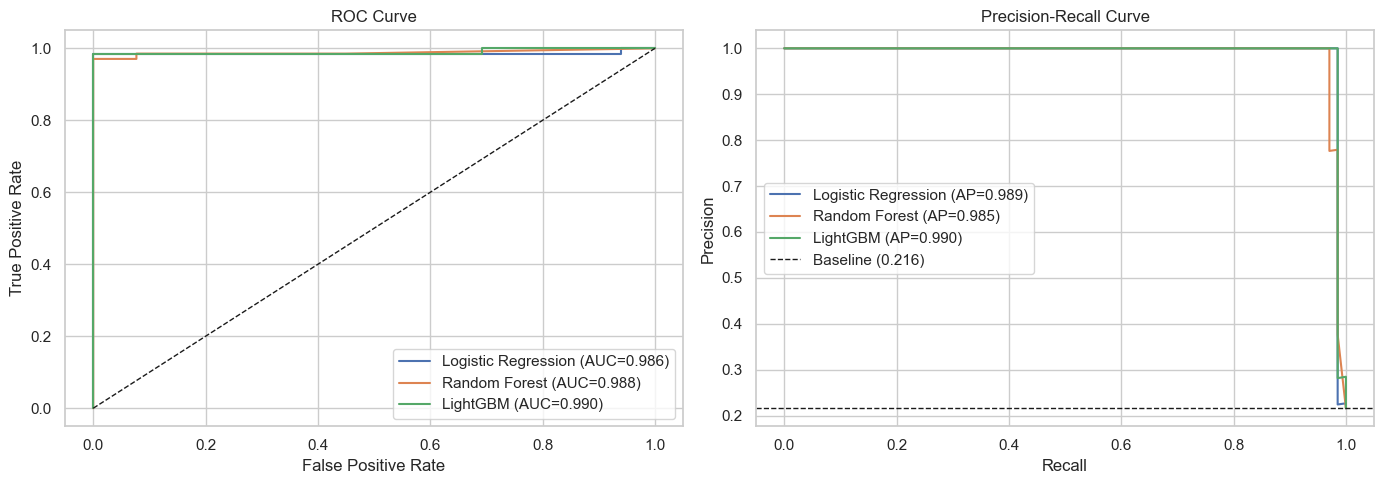


Fraud capture rate in top-ranked alerts:
  Logistic Regression: top 1% (3 alerts) → captures 3/68 fraud (4.4%)
  Random Forest: top 1% (3 alerts) → captures 3/68 fraud (4.4%)
  LightGBM: top 1% (3 alerts) → captures 3/68 fraud (4.4%)

  Logistic Regression: top 5% (15 alerts) → captures 15/68 fraud (22.1%)
  Random Forest: top 5% (15 alerts) → captures 15/68 fraud (22.1%)
  LightGBM: top 5% (15 alerts) → captures 15/68 fraud (22.1%)

  Logistic Regression: top 10% (31 alerts) → captures 31/68 fraud (45.6%)
  Random Forest: top 10% (31 alerts) → captures 31/68 fraud (45.6%)
  LightGBM: top 10% (31 alerts) → captures 31/68 fraud (45.6%)



In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10 — EVALUATION SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
section("EVALUATION SUMMARY")

if not CAN_MODEL or not METRICS:
    print("No metrics available — modeling was skipped.")
else:
    metrics_df = pd.DataFrame(METRICS).T[["roc_auc", "pr_auc", "precision", "recall", "f1"]]
    print(metrics_df.to_string())

    # ── ROC and PR curves ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    prob_map = {}
    if "Logistic Regression" in TRAINED_MODELS:
        prob_map["Logistic Regression"] = lr_prob
    if "Random Forest" in TRAINED_MODELS:
        prob_map["Random Forest"] = rf_prob
    if "LightGBM" in TRAINED_MODELS:
        prob_map["LightGBM"] = lgbm_prob

    for name, prob in prob_map.items():
        if len(np.unique(y_test)) < 2:
            break
        fpr, tpr, _ = roc_curve(y_test, prob)
        axes[0].plot(fpr, tpr, label=f"{name} (AUC={METRICS[name]['roc_auc']:.3f})")
        prec_c, rec_c, _ = precision_recall_curve(y_test, prob)
        axes[1].plot(rec_c, prec_c, label=f"{name} (AP={METRICS[name]['pr_auc']:.3f})")

    axes[0].plot([0, 1], [0, 1], "k--", lw=1)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve")
    axes[0].legend()

    baseline_pr = y_test.mean()
    axes[1].axhline(baseline_pr, color="k", linestyle="--", lw=1, label=f"Baseline ({baseline_pr:.3f})")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # ── Fraud capture at top-N ranked alerts ──────────────────────────────────
    print("\nFraud capture rate in top-ranked alerts:")
    n_fraud_test = y_test.sum()
    for pct in [0.01, 0.05, 0.10]:
        k = max(1, int(len(y_test) * pct))
        for name, prob in prob_map.items():
            top_k_idx = np.argsort(prob)[::-1][:k]
            captured   = y_test[top_k_idx].sum()
            capture_rt = captured / max(n_fraud_test, 1)
            print(f"  {name}: top {pct:.0%} ({k} alerts) → captures {captured}/{n_fraud_test} fraud ({capture_rt:.1%})")
        print()


  FEATURE IMPORTANCE & SHAP


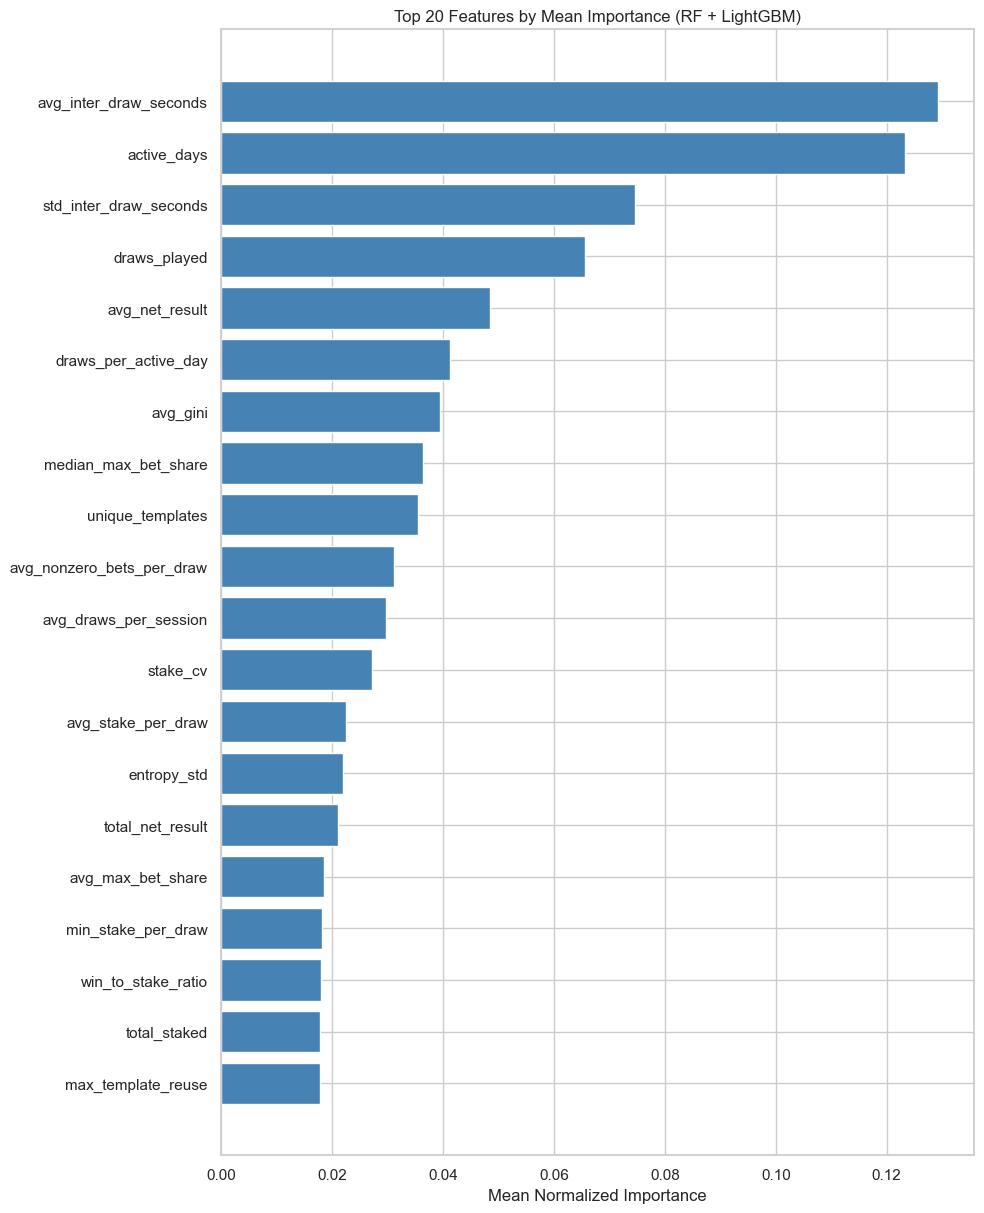


Top 15 features:
                  feature  importance
   avg_inter_draw_seconds      0.1293
              active_days      0.1233
   std_inter_draw_seconds      0.0746
             draws_played      0.0657
           avg_net_result      0.0484
     draws_per_active_day      0.0412
                 avg_gini      0.0394
     median_max_bet_share      0.0364
         unique_templates      0.0356
avg_nonzero_bets_per_draw      0.0312
    avg_draws_per_session      0.0296
                 stake_cv      0.0272
       avg_stake_per_draw      0.0225
              entropy_std      0.0220
         total_net_result      0.0211

SHAP analysis (LightGBM)...
  SHAP values shape: (315, 41)


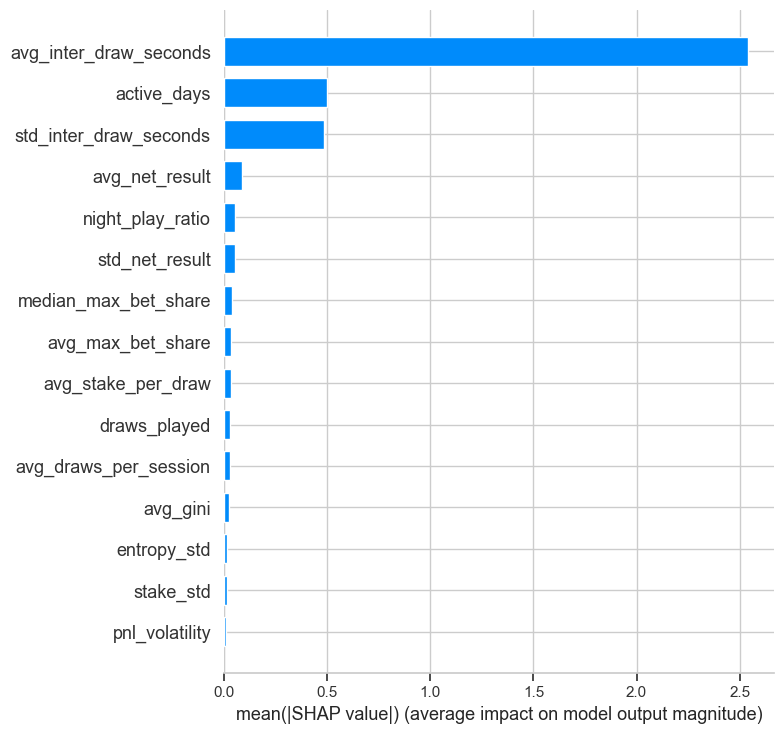

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11 — EXPLAINABILITY
# ─────────────────────────────────────────────────────────────────────────────
section("FEATURE IMPORTANCE & SHAP")

if not CAN_MODEL:
    print("Skipping — no fraud labels.")
else:
    # ── Aggregate importance from all available tree models ───────────────────
    all_imp = []
    if "Random Forest" in TRAINED_MODELS:
        all_imp.append(pd.DataFrame({
            "feature": MODEL_FEATURES,
            "importance": TRAINED_MODELS["Random Forest"].feature_importances_,
            "model": "Random Forest",
        }))
    if "LightGBM" in TRAINED_MODELS:
        all_imp.append(pd.DataFrame({
            "feature": MODEL_FEATURES,
            "importance": TRAINED_MODELS["LightGBM"].feature_importances_ / max(TRAINED_MODELS["LightGBM"].feature_importances_.sum(), 1),
            "model": "LightGBM",
        }))

    if all_imp:
        imp_combined = pd.concat(all_imp)
        imp_mean = (
            imp_combined.groupby("feature")["importance"]
            .mean()
            .sort_values(ascending=False)
            .reset_index()
        )

        fig, ax = plt.subplots(figsize=(10, max(6, len(imp_mean) * 0.3)))
        top_n = imp_mean.head(20)
        ax.barh(top_n["feature"][::-1], top_n["importance"][::-1], color="steelblue")
        ax.set_xlabel("Mean Normalized Importance")
        ax.set_title("Top 20 Features by Mean Importance (RF + LightGBM)")
        plt.tight_layout()
        plt.show()

        print("\nTop 15 features:")
        print(imp_mean.head(15).to_string(index=False))

    # ── SHAP (LightGBM only) ──────────────────────────────────────────────────
    if SHAP_AVAILABLE and "LightGBM" in TRAINED_MODELS and len(X_test_raw) >= 10:
        print("\nSHAP analysis (LightGBM)...")
        try:
            explainer = shap.TreeExplainer(TRAINED_MODELS["LightGBM"])
            shap_values = explainer.shap_values(X_test_raw)
            # shap_values may be list [class0, class1] or a single array
            if isinstance(shap_values, list):
                sv = shap_values[1]  # class 1 = fraud
            else:
                sv = shap_values
            print(f"  SHAP values shape: {sv.shape}")
            shap.summary_plot(sv, X_test_raw, feature_names=MODEL_FEATURES,
                              plot_type="bar", show=True, max_display=15)
        except Exception as e:
            print(f"  SHAP failed: {e}")
    else:
        if not SHAP_AVAILABLE:
            print("SHAP not available — install shap package.")
        elif "LightGBM" not in TRAINED_MODELS:
            print("SHAP skipped — LightGBM model not trained.")

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12 — ERROR ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
section("ERROR ANALYSIS")

if not CAN_MODEL or not TRAINED_MODELS:
    print("Skipping — no models trained.")
else:
    # Use best model by PR-AUC
    best_model_name = max(METRICS, key=lambda k: METRICS[k]["pr_auc"])
    best_prob = prob_map[best_model_name]
    print(f"Using best model for error analysis: {best_model_name} (PR-AUC={METRICS[best_model_name]['pr_auc']:.4f})")

    test_df = player_agg.iloc[X_test.index.tolist() if hasattr(X_test, 'index') else range(len(X_test))].copy() if hasattr(X_test, 'index') else X_test.copy()

    # Build analysis frame
    analysis = pd.DataFrame({
        "member_id": mid_test,
        "label":     y_test,
        "prob":      best_prob,
        "pred":      (best_prob >= 0.5).astype(int),
    })

    # Add top features for context
    top_feat_cols = ["draws_played", "total_staked", "avg_entropy",
                     "template_reuse_ratio", "avg_tiny_bet_ratio"]
    top_feat_cols = [c for c in top_feat_cols if c in MODEL_FEATURES]

    # Re-index X_test to align
    X_test_reset = X_test_raw.reset_index(drop=True)
    analysis = analysis.reset_index(drop=True)
    analysis[top_feat_cols] = X_test_reset[top_feat_cols].values

    fp = analysis[(analysis["label"] == 0) & (analysis["pred"] == 1)].sort_values("prob", ascending=False)
    fn = analysis[(analysis["label"] == 1) & (analysis["pred"] == 0)].sort_values("prob", ascending=True)
    tp = analysis[(analysis["label"] == 1) & (analysis["pred"] == 1)].sort_values("prob", ascending=False)

    print(f"\nTrue Positives  (fraud correctly flagged): {len(tp)}")
    print(f"False Positives (non-fraud flagged):       {len(fp)}")
    print(f"False Negatives (fraud missed):            {len(fn)}")

    if not fn.empty:
        print("\nTop missed fraud players (False Negatives):")
        print(fn.head(10)[["member_id", "prob"] + top_feat_cols].to_string(index=False))

    if not fp.empty:
        print("\nTop false alarm players (False Positives, highest score):")
        print(fp.head(10)[["member_id", "prob"] + top_feat_cols].to_string(index=False))


  ERROR ANALYSIS
Using best model for error analysis: LightGBM (PR-AUC=0.9895)

True Positives  (fraud correctly flagged): 67
False Positives (non-fraud flagged):       0
False Negatives (fraud missed):            1

Top missed fraud players (False Negatives):
 member_id   prob  draws_played  total_staked  avg_entropy  template_reuse_ratio  avg_tiny_bet_ratio
GK00133510 0.0022        1.0000      415.0000       4.4369                0.0000              0.0000


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13 — SAVE OUTPUTS
# ─────────────────────────────────────────────────────────────────────────────
section("SAVE OUTPUTS")

# 1. Player feature table (all players, with label)
save_cols = ["member_id", "label"] + MODEL_FEATURES
save_cols = [c for c in save_cols if c in player_agg.columns]
player_agg[save_cols].to_parquet(PLAYER_FEATURE_TABLE_PATH, index=False)
print(f"Saved player feature table    : {PLAYER_FEATURE_TABLE_PATH.name}  ({len(player_agg):,} rows)")

# 2. Feature dictionary
feat_dict_df.to_csv(FEATURE_DICT_PATH, index=False)
print(f"Saved feature dictionary       : {FEATURE_DICT_PATH.name}")

# 3. Model-ready train+test dataset
if CAN_MODEL:
    train_out = X_train_raw.copy()
    train_out["member_id"] = mid_train
    train_out["label"] = y_train
    train_out["split"] = "train"
    test_out = X_test_raw.copy()
    test_out["member_id"] = mid_test
    test_out["label"] = y_test
    test_out["split"] = "test"
    pd.concat([train_out, test_out], ignore_index=True).to_parquet(TRAIN_DATASET_PATH, index=False)
    print(f"Saved model train/test dataset : {TRAIN_DATASET_PATH.name}")

# 4. Baseline metrics
if METRICS:
    with open(METRICS_PATH, "w") as f:
        json.dump(METRICS, f, indent=2, default=str)
    print(f"Saved baseline metrics         : {METRICS_PATH.name}")

# 5. Feature importance (from best available tree model)
if all_imp:
    imp_mean.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
    print(f"Saved feature importance       : {FEATURE_IMPORTANCE_PATH.name}")

print("\nAll outputs saved to data_cache/.")


  SAVE OUTPUTS
Saved player feature table    : player_feature_table.parquet  (1,049 rows)
Saved feature dictionary       : player_feature_dictionary.csv
Saved model train/test dataset : model_train_dataset.parquet
Saved baseline metrics         : baseline_metrics.json
Saved feature importance       : feature_importance.csv

All outputs saved to data_cache/.


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 14 — CONCLUSION
# ─────────────────────────────────────────────────────────────────────────────
section("CONCLUSION")

n_fraud_in_data = (player_agg["label"] == 1).sum()
n_total = len(player_agg)

print("DATASET SUMMARY")
print(f"  Total players in modeling dataset : {n_total:,}")
print(f"  Fraud-labeled players (label=1)   : {n_fraud_in_data:,}")
print(f"  Non-fraud players     (label=0)   : {n_total - n_fraud_in_data:,}")
print(f"  Features engineered               : {len(MODEL_FEATURES)}")
print()

if not CAN_MODEL:
    print("MODELING STATUS: SKIPPED")
    print("  Reason: Insufficient fraud-labeled players in the dataset.")
    print("  Resolution: Ensure MongoDB pull captures fraud member records.")
    print("  Feature engineering pipeline is validated and ready for reuse.")
else:
    print("MODELING STATUS: COMPLETE")
    if METRICS:
        best = max(METRICS, key=lambda k: METRICS[k]["pr_auc"])
        print(f"  Best model by PR-AUC: {best}")
        print(f"    ROC-AUC : {METRICS[best]['roc_auc']}")
        print(f"    PR-AUC  : {METRICS[best]['pr_auc']}")
        print(f"    Recall  : {METRICS[best]['recall']}")
        print(f"    F1      : {METRICS[best]['f1']}")

print()
print("SIGNALS MOST LIKELY TO MATTER (from EDA + feature importance):")
print("  1. template_reuse_ratio   — repeated exact bet signatures (strongest bot signal)")
print("  2. avg_entropy            — low entropy = concentrated/scripted bets")
print("  3. avg_tiny_bet_ratio     — fraction of tiny bets per draw")
print("  4. stake_cv               — volatility of wager size")
print("  5. avg_inter_draw_seconds — cadence regularity")

print()
print("NEXT STEPS:")
print("  1. Resolve label coverage — pull full roulette history for 402 fraud members")
print("  2. Investigate 'labels' MongoDB collection for additional ground truth")
print("  3. Cross-validate with k-fold if dataset grows beyond 500 fraud players")
print("  4. Add network/graph features (shared CCS, correlated timing)")
print("  5. Threshold tune for operational precision/recall trade-off")


  CONCLUSION
DATASET SUMMARY
  Total players in modeling dataset : 1,049
  Fraud-labeled players (label=1)   : 227
  Non-fraud players     (label=0)   : 822
  Features engineered               : 41

MODELING STATUS: COMPLETE
  Best model by PR-AUC: LightGBM
    ROC-AUC : 0.9898
    PR-AUC  : 0.9895
    Recall  : 0.9853
    F1      : 0.9926

SIGNALS MOST LIKELY TO MATTER (from EDA + feature importance):
  1. template_reuse_ratio   — repeated exact bet signatures (strongest bot signal)
  2. avg_entropy            — low entropy = concentrated/scripted bets
  3. avg_tiny_bet_ratio     — fraction of tiny bets per draw
  4. stake_cv               — volatility of wager size
  5. avg_inter_draw_seconds — cadence regularity

NEXT STEPS:
  1. Resolve label coverage — pull full roulette history for 402 fraud members
  2. Investigate 'labels' MongoDB collection for additional ground truth
  3. Cross-validate with k-fold if dataset grows beyond 500 fraud players
  4. Add network/graph features (sh